In [1]:
import pandas as pd 
df = pd.read_csv(r"C:\Users\ASUS\Downloads\healthcare_data_cleaning_dataset.csv")
df

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20
...,...,...,...,...,...,...,...,...,...
5095,11764,NaN,Female,Mumbai,COVID-19,15,NaN,0,2023-09-22
5096,17597,NaN,Female,Chennai,Asthma,2,NaN,0,2023-06-26
5097,19171,NaN,Female,Mumbai,Flu,1,NaN,1,2023-12-31
5098,13854,NaN,Female,Bangalore,Flu,17,NaN,0,2023-01-18


In [2]:
# Q1. Missing Data Identification
# Scenario:
#  The hospital suspects incomplete patient records.
# Task:
# Identify missing values in each column
print('Missing values in each column')
df.isnull().sum()

Missing values in each column


Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

In [3]:
# Calculate percentage of missing data
print('percentage of missing data')
missing_persentage = (df.isnull().sum() / len(df)) * 100
print(missing_persentage)

percentage of missing data
Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


In [4]:
# Q2. Handling Missing Age
# Scenario:
#  Age is critical for medical analysis, but some values are missing.
# Task:
# Replace missing Age values with an appropriate method
df['Age'] = df['Age'].fillna(df['Age'].median())
print (f"Missing  values in Age: {df['Age'].isnull().sum()}")

Missing  values in Age: 0


Justify your choice (mean/median)
I chose the median because medical age data is often skewed by specific patient demographics. Using the median ensures that extreme outliers (very young or very old patients) do not artificially shift the 'typical' age used to fill the gaps, maintaining the statistical integrity of the clinical analysis.

In [5]:
# Q3. Handling Missing Treatment Cost
# Scenario:
#  Treatment cost is highly skewed due to expensive treatments.
# Task:
# Handle missing Treatment_Cost values
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())
print(f"Remaining missing values in Treatment_Cost: {df['Treatment_Cost'].isnull().sum()}")

Remaining missing values in Treatment_Cost: 0


Choose the correct imputation method and explain why
I chose Median Imputation because the dataset is highly skewed. In medical billing, rare and expensive treatments act as outliers that inflate the mean. The median is a robust measure of central tendency that ensures the imputed values remain representative of the majority of the distribution without being distorted by high-cost outliers.

In [6]:
# Q4. Duplicate Patient Records
# Scenario:
#  Some patient records were entered multiple times.
# Task:
# Identify duplicate rows
initial_size = len(df)
duplicate_count = df.duplicated().sum()
print(f'Number of duplicate rows found: {duplicate_count}')

Number of duplicate rows found: 99


In [8]:
# Remove duplicates
df = df.drop_duplicates()

In [9]:
# Compare dataset size before and after
final_size = len(df)
print(f'Datadet size before: {initial_size}')
print(f'Datadet size after: {final_size}')
print(f'Total rows removed: {initial_size - final_size}')

Datadet size before: 5100
Datadet size after: 5001
Total rows removed: 99


In [12]:
# Q5. Invalid Age Values (Data Quality Check) 
# Scenario:  
#Some patients have unrealistic age values (e.g., >100 or <0).
#Task: 
#Detect such records 
df_cleaned = df[(df['Age'] > 0) & (df['Age'] < 100)]
#Decide whether to remove or correct them
remaining_invalid = df_cleaned[(df_cleaned['Age'] <= 0) | (df_cleaned['Age'] >= 100)]
print(f"Invalid records remaining: {len(remaining_invalid)}")
print(f"New dataset shape: {df_cleaned.shape}")

Invalid records remaining: 0
New dataset shape: (4952, 9)


In [13]:
# Q6. Outlier Detection (Treatment Cost)

# Scenario:

#  Extreme treatment costs are affecting analysis.

# Task:

# Detect outliers using IQR method

# Display number of outliers


Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)


IQR = Q3 - Q1


lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]


print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total number of outliers detected: {len(outliers)}")

Lower Bound: -20398.0
Upper Bound: 70706.0
Total number of outliers detected: 50


In [14]:
# Q7. Outlier Treatment

# Scenario:

# The business team wants to retain all records.

# Task:

# Apply capping (Winsorization) on Treatment_Cost

# Use 5th and 95th percentile

# Calculate the 5th and 95th percentiles

lower_limit = df['Treatment_Cost'].quantile(0.05)
upper_limit = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower=lower_limit, upper=upper_limit)

print(f"5th Percentile (Lower Cap): {lower_limit}")
print(f"95th Percentile (Upper Cap): {upper_limit}")
print("-" * 30)
print(f"New Minimum Treatment Cost: {df['Treatment_Cost'].min()}")
print(f"New Maximum Treatment Cost: {df['Treatment_Cost'].max()}")

5th Percentile (Lower Cap): 3238.0
95th Percentile (Upper Cap): 47948.0
------------------------------
New Minimum Treatment Cost: 3238.0
New Maximum Treatment Cost: 47948.0


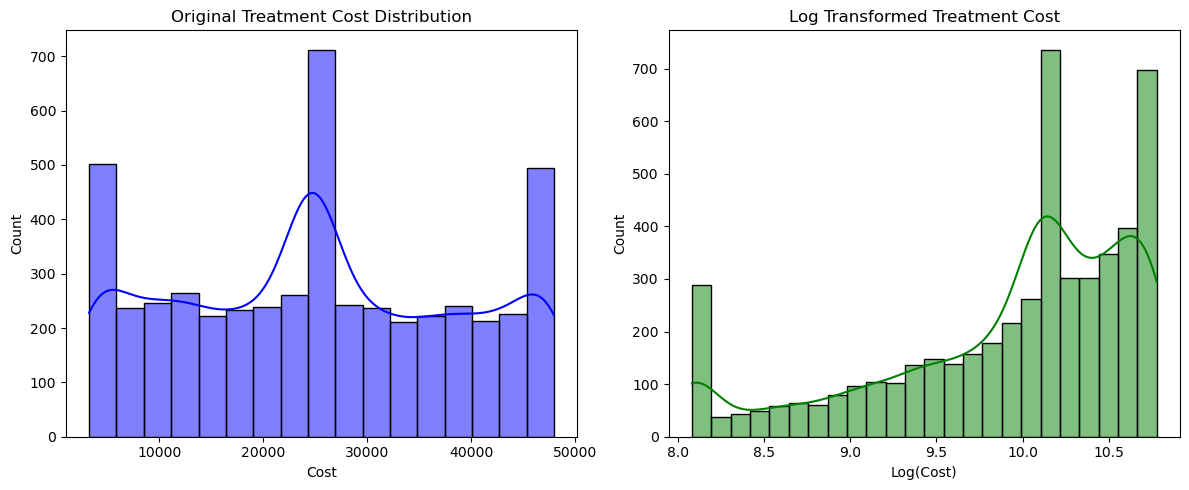

   Treatment_Cost  Log_Treatment_Cost
0         41010.0           10.621596
1         12194.0            9.408781
2         45086.0           10.716349
3         40842.0           10.617491
4          9873.0            9.197660


In [15]:
# Q8. Transformation

# Scenario:

#  Treatment cost is highly skewed.

# Task:

# Apply log transformation

# Create a new column

# Compare before vs after distribution


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Apply log transformation (using log1p to handle any potential 0 values safely)
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# 2. Compare before vs after distribution
plt.figure(figsize=(12, 5))

# Plot Original Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost'], kde=True, color='blue')
plt.title('Original Treatment Cost Distribution')
plt.xlabel('Cost')

# Plot Log Transformed Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Log_Treatment_Cost'], kde=True, color='green')
plt.title('Log Transformed Treatment Cost')
plt.xlabel('Log(Cost)')

plt.tight_layout()
plt.show()

# Display first few rows to verify the new column
print(df[['Treatment_Cost', 'Log_Treatment_Cost']].head())

In [29]:
# Q9. Time-Based Missing Handling

# Scenario:

#  Admission dates should follow a logical sequence.

# Task:

# Sort data by Admission_Date
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values('Admission_Date')
